<a href="https://colab.research.google.com/github/cristianalethangads2/projetoads3/blob/main/projetoads.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sobre a aluna e o projeto

Aluna: Cristiana Lethang Cardozo dos Santos

Projeto: Análise de Dados no dataset HAM10000

Software Product: Analysis, Specification, Project & Implementation
202601 - EAD - ADS 5A

Faculdade Impacta

Professor Antonio de Oliveira Dias


# Imports

In [ ]:
# Visualização
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.image as mpimg
from PIL import Image

# Geral
import numpy as np
import pandas as pd

# System
import os

from glob import glob
import shutil

import seaborn as sns

# Estilos do Seaborn para melhorar a estética
sns.set(style="whitegrid")
spectral = sns.color_palette("Spectral", as_cmap=True)

# Criando o dataframe do Pandas

Sobre o dataset
O HAM10000 (HAM = Human Against the Machine) é um banco de dados público com 10.015 imagens dermatoscópicas de várias lesões de pele.

Fonte:
https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000?resource=download

Legendas das lesões (ENG-PT):

nv = melanocytic nevi - nevo melanocítico

mel = melanoma - melanoma

bkl = benign keratosis-like lesions - lesões ceratose-like benignas

bcc = basal cell carcinoma - carcinoma basocelular

akiec = actinic keratoses - ceratose actínica

vasc = vascular lesions - lesões vasculares

df = dermatofibroma - dermatofibroma


In [ ]:
# Install gdown if not already installed
!pip install gdown -q

import gdown

ham10000_file_id = '1-5rwLqyWF5WcRFhXB_ZquDD1j-sBoeGl'
file_name = 'skin_df.csv' # Define a local filename

# Use the direct download link from the kernel state
ham10000_file_direct_link = f'https://drive.google.com/uc?export=download&id={ham10000_file_id}'

# Try downloading the file using wget instead of gdown
!wget --no-check-certificate '{ham10000_file_direct_link}' -O '{file_name}'

# Read the CSV file into a pandas DataFrame from the local file
skin_df = pd.read_csv(file_name)

--2026-03-22 18:29:42--  https://drive.google.com/uc?export=download&id=1-5rwLqyWF5WcRFhXB_ZquDD1j-sBoeGl
Resolving drive.google.com (drive.google.com)... 172.253.63.139, 172.253.63.100, 172.253.63.113, ...
Connecting to drive.google.com (drive.google.com)|172.253.63.139|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1-5rwLqyWF5WcRFhXB_ZquDD1j-sBoeGl&export=download [following]
--2026-03-22 18:29:42--  https://drive.usercontent.google.com/download?id=1-5rwLqyWF5WcRFhXB_ZquDD1j-sBoeGl&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 172.253.62.132, 2607:f8b0:4004:c07::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|172.253.62.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2345964 (2.2M) [application/octet-stream]
Saving to: ‘skin_df.csv’

skin_df.csv         100%[===================>]   2.24M  10.2MB/s   

# Análise Exploratória dos Dados

In [ ]:
skin_df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,image_path,image
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/content/drive/MyDrive/PUCRS/Ap Profundo 2/HAM...,<PIL.JpegImagePlugin.JpegImageFile image mode=...
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/content/drive/MyDrive/PUCRS/Ap Profundo 2/HAM...,<PIL.JpegImagePlugin.JpegImageFile image mode=...
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/content/drive/MyDrive/PUCRS/Ap Profundo 2/HAM...,<PIL.JpegImagePlugin.JpegImageFile image mode=...
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/content/drive/MyDrive/PUCRS/Ap Profundo 2/HAM...,<PIL.JpegImagePlugin.JpegImageFile image mode=...
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/content/drive/MyDrive/PUCRS/Ap Profundo 2/HAM...,<PIL.JpegImagePlugin.JpegImageFile image mode=...


In [ ]:
# Informações básicas do dataset
print(f"Number of samples: {len(skin_df)}")
print(f"Columns in the dataset: {skin_df.columns.tolist()}")
print(f"Number of missing values:\n{skin_df.isnull().sum()}")

# Resumo das estatísticas
print(skin_df.describe())

Number of samples: 10015
Columns in the dataset: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization', 'image_path', 'image']
Number of missing values:
lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
image_path       0
image            0
dtype: int64
               age
count  9958.000000
mean     51.863828
std      16.968614
min       0.000000
25%      40.000000
50%      50.000000
75%      65.000000
max      85.000000


In [ ]:
print(skin_df['dx'].value_counts())

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [ ]:
skin_df.nunique()

,0
lesion_id,7470
image_id,10015
dx,7
dx_type,4
age,18
sex,3
localization,15
image_path,10015
image,10015


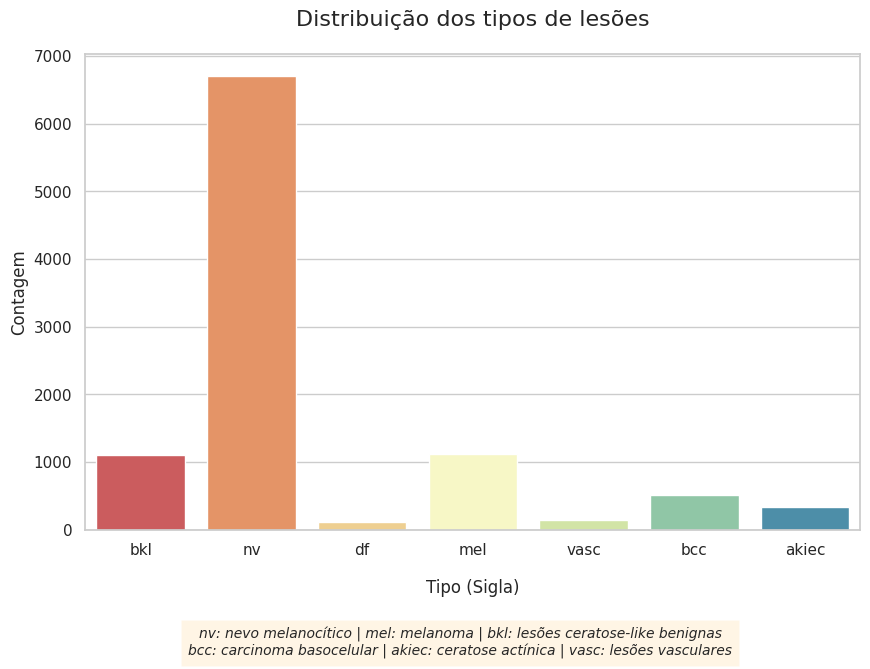

In [ ]:
# Definir uma paleta discreta usando cores da paleta "Spectral"
discrete_palette = sns.color_palette("Spectral", n_colors=7)

# Definindo o dicionário de mapeamento para facilitar a legenda
legenda_texto = (
    "nv: nevo melanocítico | mel: melanoma | bkl: lesões ceratose-like benignas\n"
    "bcc: carcinoma basocelular | akiec: ceratose actínica | vasc: lesões vasculares"
)

# Distribuição dos tipos
plt.figure(figsize=(10, 7))
sns.countplot(x='dx', data=skin_df, palette=discrete_palette, hue='dx', legend=False)

plt.title('Distribuição dos tipos de lesões', fontsize=16, pad=20)
plt.ylabel('Contagem', fontsize=12)
plt.xlabel('Tipo (Sigla)', fontsize=12, labelpad=15)

# Adicionando o texto na parte inferior da figura
plt.figtext(0.5, 0.02, legenda_texto, ha="center", fontsize=10,
            bbox={"facecolor":"orange", "alpha":0.1, "pad":5}, style='italic')
plt.subplots_adjust(bottom=0.2)

plt.show()

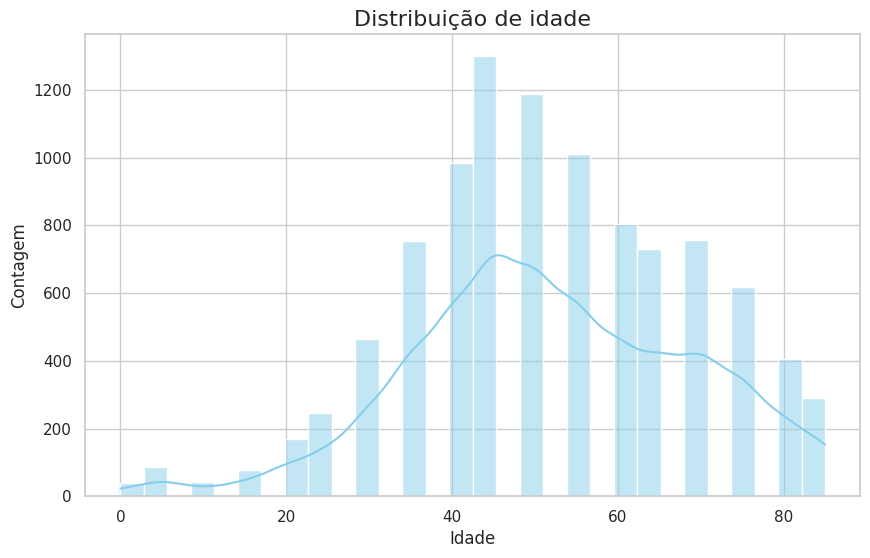

In [ ]:
# Idade
plt.figure(figsize=(10, 6))
sns.histplot(skin_df['age'], bins=30, kde=True, color='skyblue')
plt.title('Distribuição de idade', fontsize=16)
plt.xlabel('Idade')
plt.ylabel('Contagem')
plt.show()

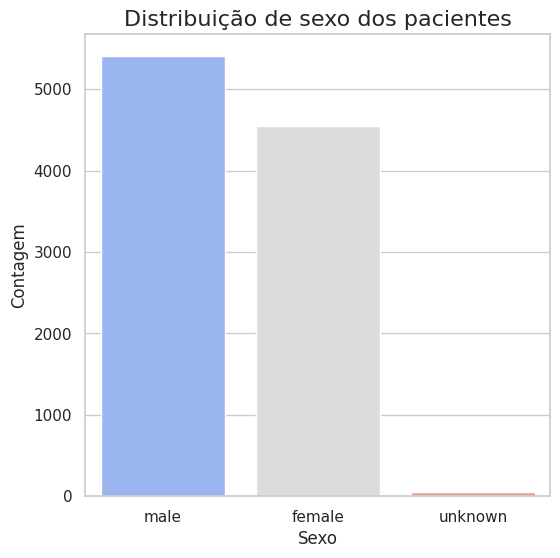

In [ ]:
# Sexo
plt.figure(figsize=(6, 6))
sns.countplot(data=skin_df, x='sex', hue='sex', palette='coolwarm', legend=False)
plt.title('Distribuição de sexo dos pacientes', fontsize=16)
plt.xlabel('Sexo')
plt.ylabel('Contagem')
plt.show()

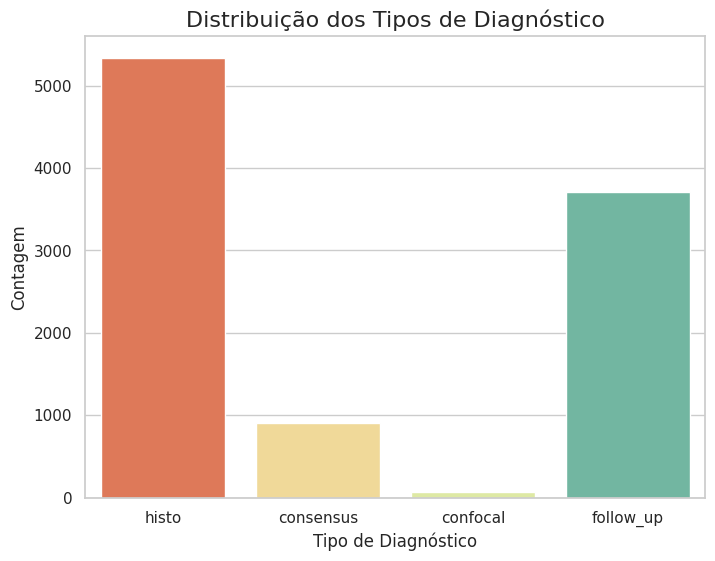

In [ ]:
# Definir uma paleta discreta usando cores da paleta "Spectral"
discrete_palette = sns.color_palette("Spectral", n_colors=4)

# Visualizar a distribuição dos tipos de diagnóstico
plt.figure(figsize=(8, 6))

# Correção: Adicionado hue='dx_type' e legend=False
sns.countplot(data=skin_df, x='dx_type', hue='dx_type', palette=discrete_palette, legend=False)

plt.title('Distribuição dos Tipos de Diagnóstico', fontsize=16)
plt.xlabel('Tipo de Diagnóstico')
plt.ylabel('Contagem')
plt.show()

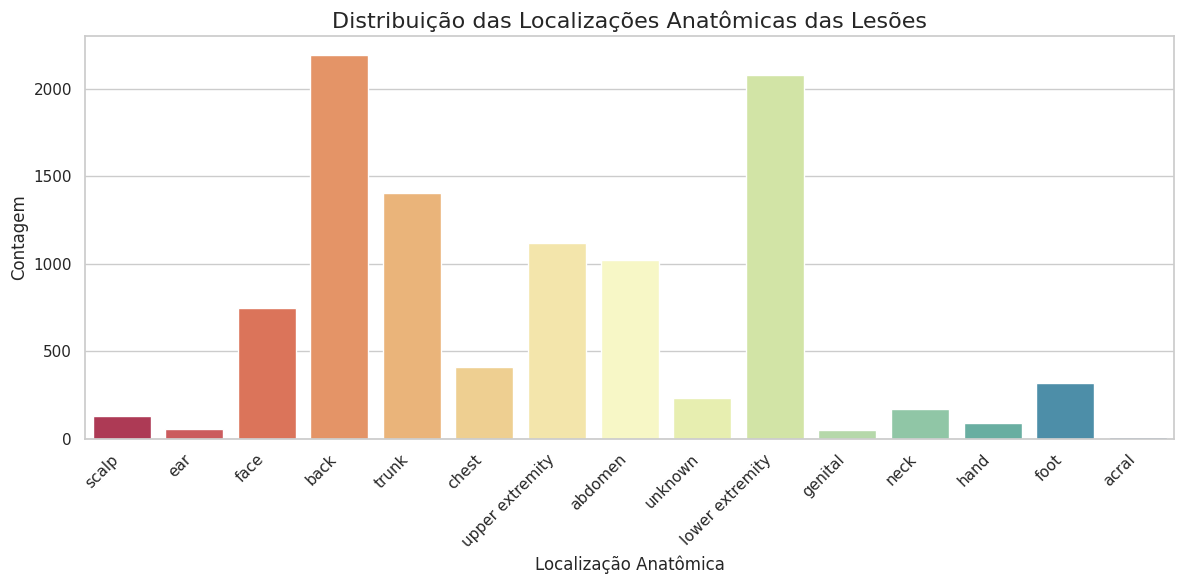

In [ ]:
# Definir uma paleta discreta usando cores da paleta "Spectral"
discrete_palette = sns.color_palette("Spectral", n_colors=15)

# Visualizar a distribuição das localizações anatômicas
plt.figure(figsize=(12, 6))

sns.countplot(
    data=skin_df,
    x='localization',
    hue='localization',
    palette=discrete_palette,
    legend=False
)

plt.title('Distribuição das Localizações Anatômicas das Lesões', fontsize=16)
plt.xlabel('Localização Anatômica')
plt.ylabel('Contagem')

# Rotacionar os rótulos do eixo x para melhor visualização
plt.xticks(rotation=45, ha='right')

plt.tight_layout() # Evita que os nomes das localizações fiquem fora da imagem
plt.show()

# Entrega AC1

Distribuição Anatômica de Lesões: Homens vs Mulheres - Mapa de calor

Essa análise toca na biologia comportamental, tentando demonstrar os diferentes  padrões de exposição ao sol entre os sexos: homens fazem mais trabalho braçal e espera-se que tenham mais lesões no dorso, enquanto mulheres expõe-se mais ao sol para se bronzear, e passam menos protetor solar nas pernas, portanto espera-se uma maior quantidade de melanoma nas pernas

Calculamos a proporção (%) dentro de cada sexo. Isso evita que o mapa pareça "mais quente" para os homens, pois, como vimos, o dataset possui um pouco mais de homens do que mulheres.

Diferença nas Pernas (lower extremity): Na literatura, as mulheres costumam ter uma concentração significativamente maior de lesões nas pernas do que os homens. Se o seu gráfico mostrar isso, você pode citar que isso reflete hábitos históricos de vestimenta e exposição solar.

Diferença no Tronco (back / trunk): Homens tendem a apresentar mais lesões no dorso e tronco.

Equilíbrio na Face: Regiões como face e scalp costumam ser áreas de alta incidência para ambos, mas o couro cabeludo (scalp) tende a ser mais frequente em homens (devido à calvície e falta de proteção capilar contra o sol).

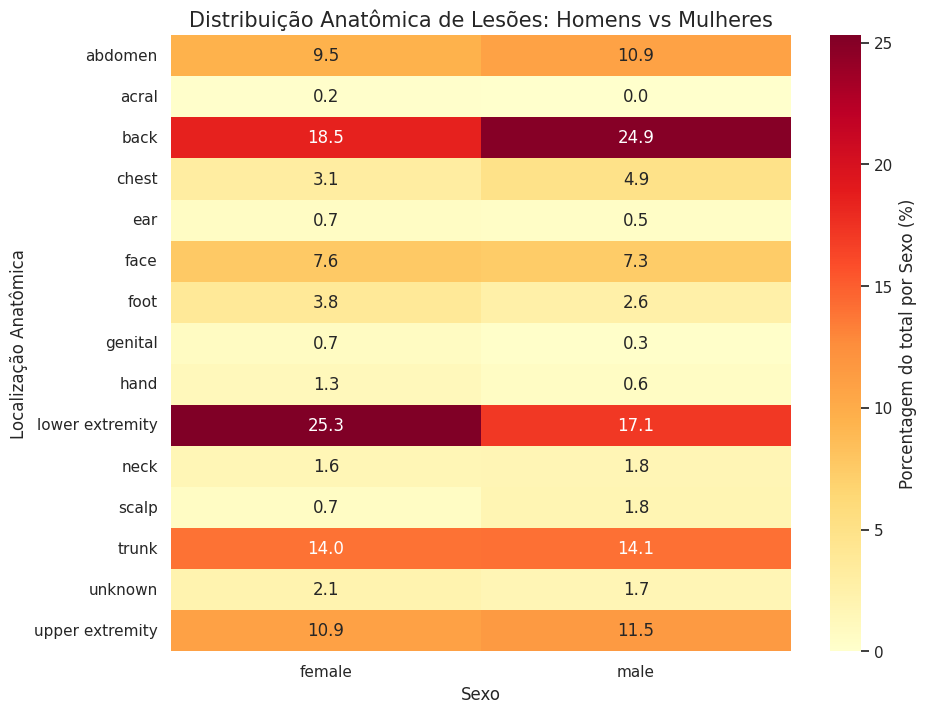

In [ ]:
# Limpeza básica: remover sexos 'unknown' para uma comparação limpa
df_filtered = skin_df[skin_df['sex'].isin(['male', 'female'])].copy()

# Criar uma tabela de frequências (Crosstab)
ctab = pd.crosstab(df_filtered['localization'], df_filtered['sex'])

# Normalização
ctab_pct = ctab.div(ctab.sum(axis=0), axis=1) * 100

plt.figure(figsize=(10, 8))
sns.heatmap(ctab_pct,
            annot=True,      # Mostra os números dentro dos quadrados
            fmt=".1f",       # Formata para 1 casa decimal
            cmap="YlOrRd",   # Cores: Amarelo para Vermelho (quente)
            cbar_kws={'label': 'Porcentagem do total por Sexo (%)'})

plt.title('Distribuição Anatômica de Lesões: Homens vs Mulheres', fontsize=15)
plt.ylabel('Localização Anatômica')
plt.xlabel('Sexo')
plt.show()

Podemos observar:

Diferença nas Pernas (lower extremity): Na literatura, as mulheres costumam ter uma concentração significativamente maior de lesões nas pernas do que os homens. Meu gráfico mostrar isso, o que reflete os hábitos históricos de vestimenta e exposição solar nas mulheres.

Diferença no Tronco (back): Homens tendem a apresentar mais lesões no dorso, e também podemos evidenciar isso em meu gráfico.

Couro cabeludo (scalp): tende a ser mais frequente em homens (devido à calvície e falta de proteção capilar contra o sol).

Referência bibliográfica:  Hematol Oncol Clin North Am. 2024 Jun 15;38(5):939–952. doi: 10.1016/j.hoc.2024.05.005  - Nevi and Melanoma - Yifan Zhang 1, Stephen M Ostrowski 1, David E Fisher 1

## Filtrando melanoma

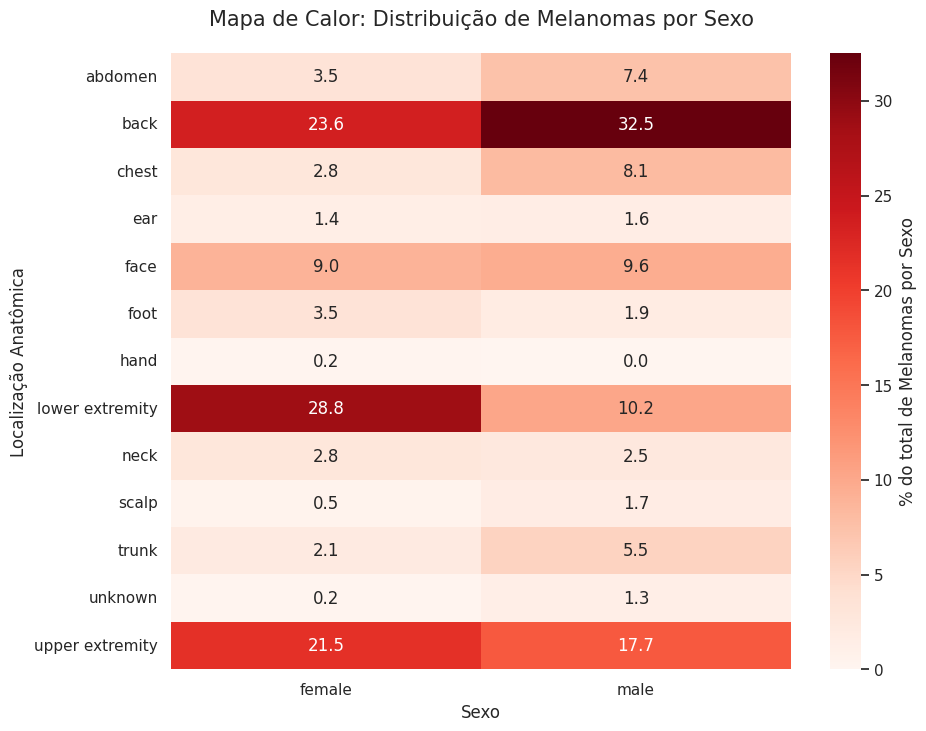

In [ ]:
# Filtrar apenas casos de Melanoma ('mel') e remover sexos desconhecidos
mel_df = skin_df[(skin_df['dx'] == 'mel') & (skin_df['sex'].isin(['male', 'female']))].copy()

# Criar a tabela de frequências (Localização x Sexo)
ctab_mel = pd.crosstab(mel_df['localization'], mel_df['sex'])

# Normalização por Coluna
ctab_mel_pct = ctab_mel.div(ctab_mel.sum(axis=0), axis=1) * 100

plt.figure(figsize=(10, 8))
sns.heatmap(ctab_mel_pct,
            annot=True,      # Mostra o valor percentual dentro do quadrado
            fmt=".1f",       # Formata para uma casa decimal
            cmap="Reds",     # Tons de vermelho para destacar áreas críticas
            cbar_kws={'label': '% do total de Melanomas por Sexo'})

plt.title('Mapa de Calor: Distribuição de Melanomas por Sexo', fontsize=15, pad=20)
plt.ylabel('Localização Anatômica')
plt.xlabel('Sexo')
plt.show()

Conforme esperado, podemos ver que, filtrando o melanoma, as diferenças encontradas anteriormente tornaram-se ainda mais evidentes.

# Entrega AC2

Análise e exposição solar vs malginidade das lesões

Farei agrupamento das localizações em duas categorias: "Alta Exposição" (rosto, orelhas, pescoço, mãos) e "Baixa/Média Exposição" (abdome, costas, peito), e a seguir compararei a taxa de malignidade entre os grupos.

Esperado pela Literatura: Carcinomas Basocelulares (BCC) e Ceratoses Actínicas (AKIEC) são fortemente ligados ao dano solar acumulado e devem estar concentrados no grupo de "Alta Exposição".

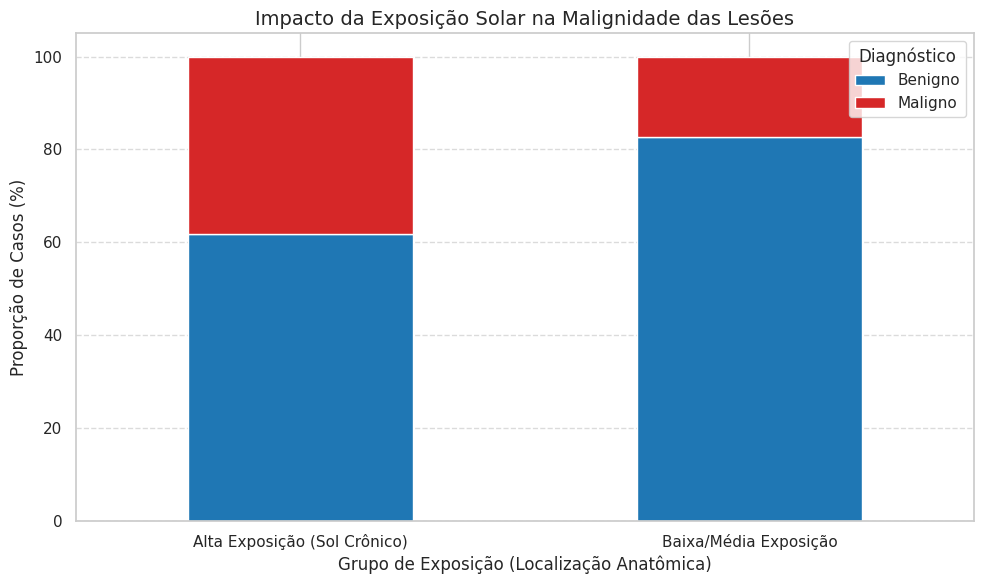

In [ ]:
# 1. Definir os grupos de exposição solar baseados na localização
high_exposure = ['face', 'scalp', 'ear', 'hand', 'neck']
low_exposure = ['trunk', 'back', 'abdomen', 'chest', 'lower extremity', 'upper extremity', 'foot', 'genital', 'acral']

# 2. Criar a nova coluna 'exposure_group'
def classify_exposure(loc):
    if loc in high_exposure:
        return 'Alta Exposição (Sol Crônico)'
    elif loc in low_exposure:
        return 'Baixa/Média Exposição'
    else:
        return 'Desconhecido'

skin_df['exposure_group'] = skin_df['localization'].apply(classify_exposure)

# 3. Definir o que é Maligno vs Benigno
# Malignos: mel (Melanoma), bcc (Basal Cell), akiec (Ceratose Actínica)
malignant_types = ['mel', 'bcc', 'akiec']
skin_df['is_malignant'] = skin_df['dx'].apply(lambda x: 'Maligno' if x in malignant_types else 'Benigno')

# 4. Calcular a porcentagem de casos malignos por grupo de exposição
exposure_comparison = skin_df[skin_df['exposure_group'] != 'Desconhecido'].copy()
summary = exposure_comparison.groupby(['exposure_group', 'is_malignant']).size().unstack(fill_value=0)
summary_pct = summary.div(summary.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10, 6))
summary_pct.plot(kind='bar', stacked=True, color=['#1f77b4', '#d62728'], ax=plt.gca())

plt.title('Impacto da Exposição Solar na Malignidade das Lesões', fontsize=14)
plt.ylabel('Proporção de Casos (%)')
plt.xlabel('Grupo de Exposição (Localização Anatômica)')
plt.xticks(rotation=0)
plt.legend(title='Diagnóstico', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

A literatura médica afirma que o Carcinoma Basocelular (BCC), a Ceratose Actínica (AKIEC) e o melanoma (mel) são causados pelo dano solar acumulado ao longo de décadas. E foi justamente isso que encontramos nessa análise: uma proporção significativamente maior dessas lesões no grupo de "Alta Exposição".

## Parte 2 da análise

O "Viés do Paciente": Muitas pessoas só procuram o médico quando a lesão está em um lugar visível (rosto). Vamos investigar se o grupo de "Alta Exposição" tem uma taxa de diagnóstico por biópsia (dx_type = 'histo') maior, o que indicaria que médicos são mais agressivos investigando lesões em áreas mais expostas.

/tmp/ipython-input-3157770661.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bias_analysis, x='exposure_group', y='taxa_biopsia_pct', palette='viridis')


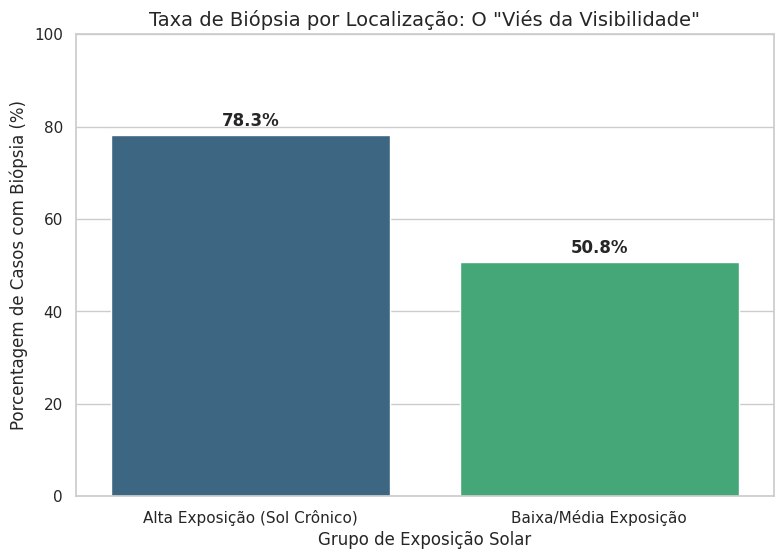

In [ ]:
# 1. Criar uma coluna booleana: É biópsia (padrão-ouro) ou não?
# No HAM10000, 'histo' significa que houve biópsia/histopatologia.
skin_df['is_biopsy'] = skin_df['dx_type'] == 'histo'

# 2. Filtrar apenas os grupos de exposição conhecidos
df_bias = skin_df[skin_df['exposure_group'] != 'Desconhecido'].copy()

# 3. Calcular a porcentagem de biópsias por grupo de exposição
bias_analysis = df_bias.groupby('exposure_group')['is_biopsy'].mean() * 100
bias_analysis = bias_analysis.reset_index().rename(columns={'is_biopsy': 'taxa_biopsia_pct'})

plt.figure(figsize=(9, 6))
sns.barplot(data=bias_analysis, x='exposure_group', y='taxa_biopsia_pct', palette='viridis')

plt.title('Taxa de Biópsia por Localização: O "Viés da Visibilidade"', fontsize=14)
plt.ylabel('Porcentagem de Casos com Biópsia (%)')
plt.xlabel('Grupo de Exposição Solar')
plt.ylim(0, 100) # Para dar perspectiva real da proporção

# Adicionar os valores em cima das barras para facilitar a leitura
for i, val in enumerate(bias_analysis['taxa_biopsia_pct']):
    plt.text(i, val + 2, f'{val:.1f}%', ha='center', fontweight='bold')

plt.show()

Essa análise mostra a psicologia do diagnóstico. Se uma mancha está no rosto (Alta Exposição), o paciente se preocupa mais e o médico tende a ser mais cauteloso, solicitando a biópsia (o dx_type = histo) para descartar câncer. Foi realemnte isso que encontramos nessa análise.

Podemos inferir que:

Aparência importa: Lesões em locais visíveis (rosto/pescoço) geram mais ansiedade no paciente, levando-os ao médico mais rápido.

Agressividade Médica: Médicos hesitam menos em biopsiar uma mancha no rosto que mudou de cor do que uma mancha nas costas que o paciente nem consegue ver direito.

A literatura médica confirma que áreas de alta exposição solar realmente têm mais cânceres malignos (BCC e AKIEC). Como esses tipos de câncer exigem biópsia para confirmação, a taxa de biópsia naturalmente sobe nesses locais. Ou seja, nem tudo é psicologia ou comportamento.

Uma pergunta provocadora que fica é:
Será que estamos deixando de diagnosticar cânceres em áreas cobertas (como abdome) porque os pacientes não as monitoram com a mesma frequência que monitoram o rosto?

# Entrega AC3

Curva de Risco por Idade (Malignidade vs. Tempo)
Criaremos um gráfico de densidade de probabilidade de ser "Maligno" (Melanoma, BCC, AKIEC) vs. "Benigno" (demais lesões) ao longo da idade.

Esperado pela Literatura: O risco de câncer de pele aumenta exponencialmente com a idade devido ao dano cumulativo no DNA.

O que checar: Existe algum "ponto de virada" (ex: após os 50 anos) onde a chance de uma lesão ser maligna ultrapassa a de ser benigna no HAM10000?

O objetivo é demonstrar como o envelhecimento atua como um fator acumulativo de risco.

Para isso, vamos usar o KDE (Kernel Density Estimate), que cria uma curva suavizada da distribuição, e depois calcularemos a Probabilidade Real de Malignidade por faixa etária.

/tmp/ipykernel_5961/1892127504.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_curve = df_age.groupby('age_bin')['is_malignant_num'].mean() * 100


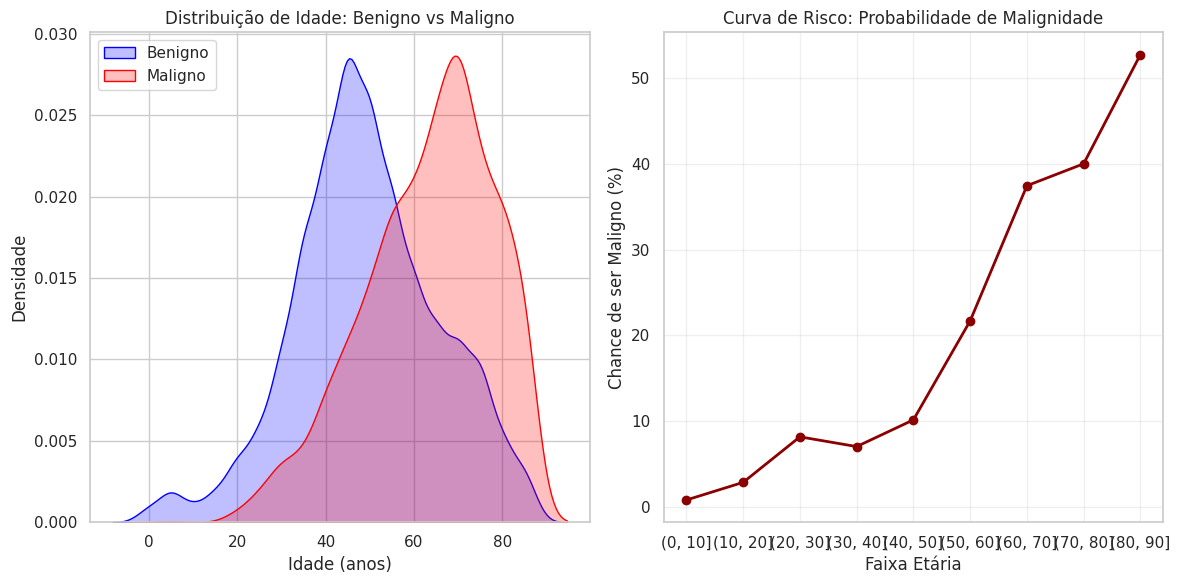

In [ ]:
# Definindo Malignos (mel, bcc, akiec) e Benignos (nv, bkl, df, vasc)
malignant_types = ['mel', 'bcc', 'akiec']
skin_df['target'] = skin_df['dx'].apply(lambda x: 'Maligno' if x in malignant_types else 'Benigno')

# Remover idades nulas para não quebrar o gráfico
df_age = skin_df.dropna(subset=['age']).copy()

# Gráfico 1: Distribuição de densidade
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.kdeplot(data=df_age[df_age['target'] == 'Benigno'], x='age', fill=True, label='Benigno', color='blue')
sns.kdeplot(data=df_age[df_age['target'] == 'Maligno'], x='age', fill=True, label='Maligno', color='red')
plt.title('Distribuição de Idade: Benigno vs Maligno')
plt.xlabel('Idade (anos)')
plt.ylabel('Densidade')
plt.legend()

# 3. Gráfico 2: Curva de Probabilidade Real (Risco)
plt.subplot(1, 2, 2)

# Criando faixas etárias (bins) de 10 em 10 anos
df_age['age_bin'] = pd.cut(df_age['age'], bins=range(0, 101, 10))

# Calculando a média de malignidade por faixa (is_malignant será 1 ou 0)
df_age['is_malignant_num'] = (df_age['target'] == 'Maligno').astype(int)
risk_curve = df_age.groupby('age_bin')['is_malignant_num'].mean() * 100

# Plotando a linha de tendência de risco
risk_curve.plot(kind='line', marker='o', color='darkred', linewidth=2)
plt.title('Curva de Risco: Probabilidade de Malignidade')
plt.xlabel('Faixa Etária')
plt.ylabel('Chance de ser Maligno (%)')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Esperado pela Literatura: O risco de câncer de pele aumenta exponencialmente com a idade devido ao dano cumulativo no DNA.

No gráfico de densidade podemos ver que a média de idade dos pacientes com lesões benignas é menor que a média de idade dos pacientes com lesões malignas.

No primeiro gráfico (KDE), podemos notar que a curva azul (Benignos) tem um pico em pessoas mais jovens (40 anos), enquanto a vermelha (Malignos) se desloca para a direita, com pico ao redor dos 70 anos.

Isso ocorre porque as lesões benignas como nevos costumam aparecer na infância/adolescência e se estabilizam. Já o câncer de pele é resultado do dano cumulativo ao DNA das células basais e melanócitos.

E na Curva de risco podemos ver que a chance de ser maligno aumenta consideravelmente após a faixa etária dos 40-50 anos. E após os 60 anos, a probabilidade de uma lesão suspeita ser maligna no dataset últrapassa os 40%.

Ambos achados são compatíveis com a literatura atual.


# Entrega Final


Detecção de Viés de Seleção (Dataset vs. Mundo Real) no HAM10000

Compararemos a distribuição percentual das lesões do HAM10000 com estatísticas do Instituto Nacional do câncer (INCA/SBD), que é muito semelhante às estatísticas globais.

O esperado pela Literatura é que o Carcinoma Basocelular (BCC) seja muito mais frequente que o Melanoma.

Vamos criar um código que compare a distribuição de nosso dataset com as estatísticas epidemiológicas do INCA/SBD (Brasil).

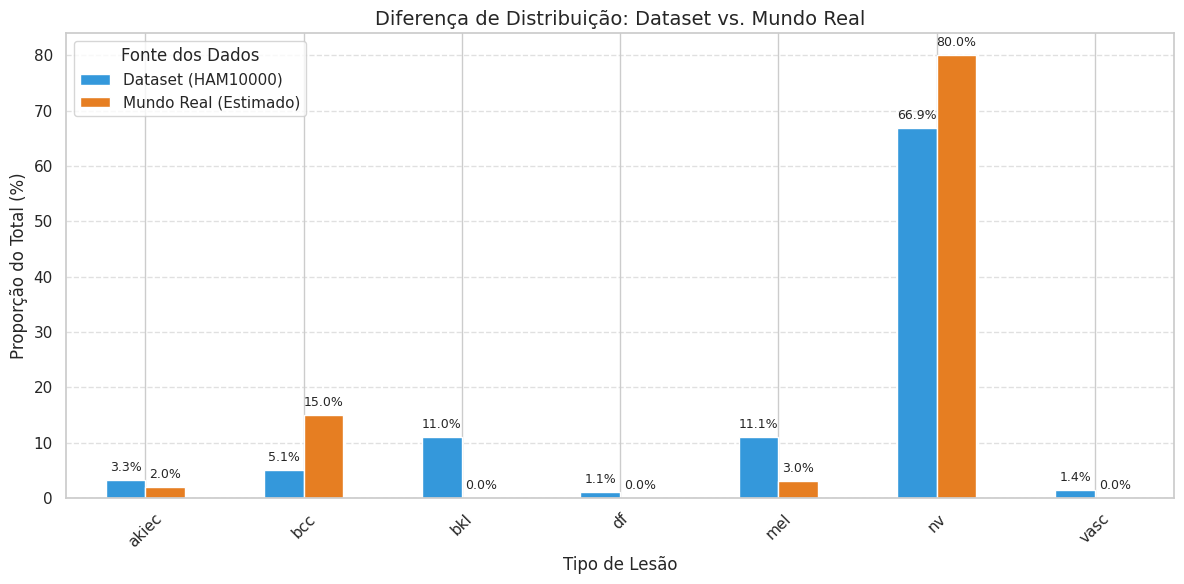

In [ ]:
# Calcular a distribuição percentual
total_casos = len(skin_df)
contagem_dataset = skin_df['dx'].value_counts(normalize=True) * 100

# Definir dados de referência (Estimativas aproximadas baseadas no INCA/SBD)
# Nota: No mundo real, BCC representa ~70-80% dos cânceres de pele,
# enquanto o Melanoma representa apenas ~3-5%.
referencia_mundo_real = {
    'nv': 80.0,    # Nevos são a vasta maioria das lesões em triagem
    'bcc': 15.0,   # Muito comum
    'mel': 3.0,    # Raro, mas perigoso
    'akiec': 2.0,  # Comum em idosos
}

# 3. Preparar DataFrame para comparação
df_comp = pd.DataFrame({
    'Dataset (HAM10000)': contagem_dataset,
    'Mundo Real (Estimado)': pd.Series(referencia_mundo_real)
}).fillna(0) # Preencher tipos raros que não incluímos na referência simplificada

# 4. Plotar a comparação
ax = df_comp.plot(kind='bar', figsize=(12, 6), color=['#3498db', '#e67e22'])

plt.title('Diferença de Distribuição: Dataset vs. Mundo Real', fontsize=14)
plt.ylabel('Proporção do Total (%)')
plt.xlabel('Tipo de Lesão')
plt.xticks(rotation=45)
plt.legend(title='Fonte dos Dados')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Adicionar as porcentagens em cima das barras para destaque
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9),
                textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()

Podemos observar que no HAM10000, o Melanoma (1113 casos) é mais frequente que o BCC (514 casos). Por que? Pois normalmente datasets de pesquisa tendem a super-representar casos perigosos para treinar melhor os modelos de IA.

Identificar esse viés de seleção (sampling bias) foi fundamental, caso desejamos usar esse dataset em uma pesquisa futura, deveremso ressaltar esse problema encontrado, pois isso pode prejudicar algumas análises.

No mundo real, o Carcinoma Basocelular (BCC) é o câncer de pele mais comum de todos. No entanto, no HAM10000, o Melanoma (muito mais raro na população) tem o dobro de casos que o BCC.

In [ ]:
servar